In [ ]:
!pip install kaggle --quiet

In [ ]:

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"petal2025","key":"c88a6e1381bcb3683557de000aaecce3"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d lainguyn123/student-performance-factors
!kaggle datasets download -d eldarsarajlic/college-enrollment-in-the-us-20032021
!kaggle datasets download -d raymondtoo/the-world-university-rankings-2016-2024
!kaggle datasets download -d thedevastator/higher-education-predictors-of-student-retention
!kaggle datasets download -d jeromeblanchet/drivendatas-boxplots-for-education-dataset

Dataset URL: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
License(s): CC0-1.0
  0% 0.00/93.9k [00:00<?, ?B/s]
100% 93.9k/93.9k [00:00<00:00, 90.0MB/s]
Dataset URL: https://www.kaggle.com/datasets/eldarsarajlic/college-enrollment-in-the-us-20032021
License(s): unknown
  0% 0.00/819 [00:00<?, ?B/s]
100% 819/819 [00:00<00:00, 3.23MB/s]
Dataset URL: https://www.kaggle.com/datasets/raymondtoo/the-world-university-rankings-2016-2024
License(s): MIT
  0% 0.00/622k [00:00<?, ?B/s]
100% 622k/622k [00:00<00:00, 1.07GB/s]
Dataset URL: https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention
License(s): CC0-1.0
  0% 0.00/87.2k [00:00<?, ?B/s]
100% 87.2k/87.2k [00:00<00:00, 197MB/s]
Dataset URL: https://www.kaggle.com/datasets/jeromeblanchet/drivendatas-boxplots-for-education-dataset
License(s): unknown
  0% 0.00/20.7M [00:00<?, ?B/s]
100% 20.7M/20.7M [00:00<00:00, 1.29GB/s]


In [ ]:
!unzip -q student-performance-factors.zip -d student_performance
!unzip -q college-enrollment-in-the-us-20032021.zip -d college_enrollment
!unzip -q the-world-university-rankings-2016-2024.zip -d university_rankings
!unzip -q higher-education-predictors-of-student-retention.zip -d retention
!unzip -q drivendatas-boxplots-for-education-dataset.zip -d education

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.ion()


In [ ]:
%matplotlib inline

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


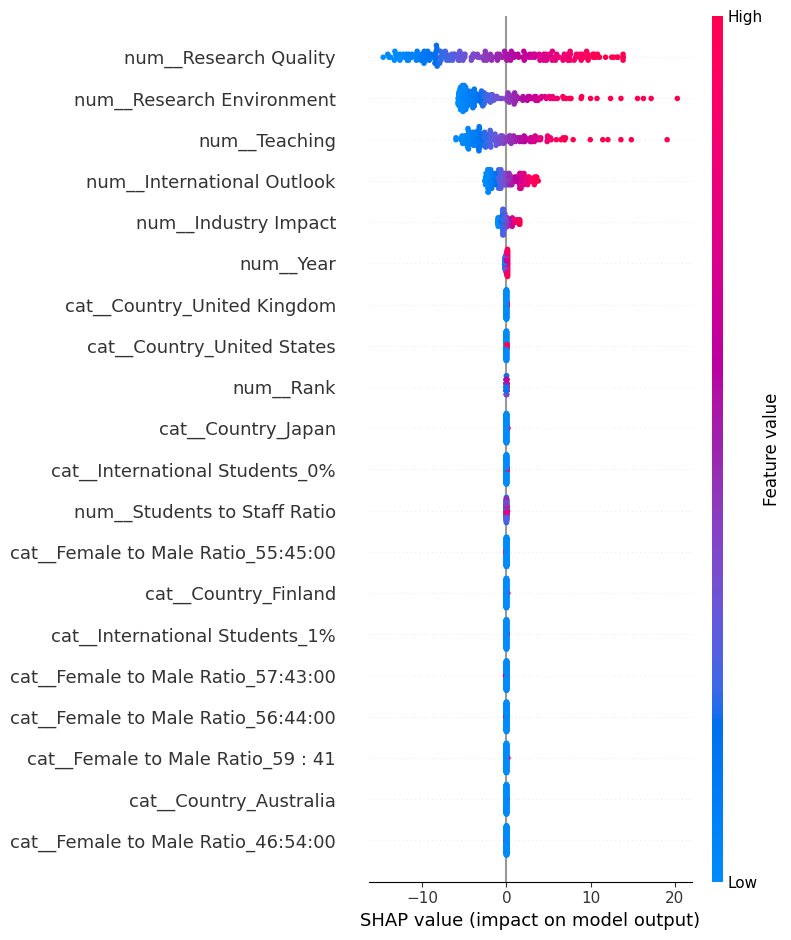

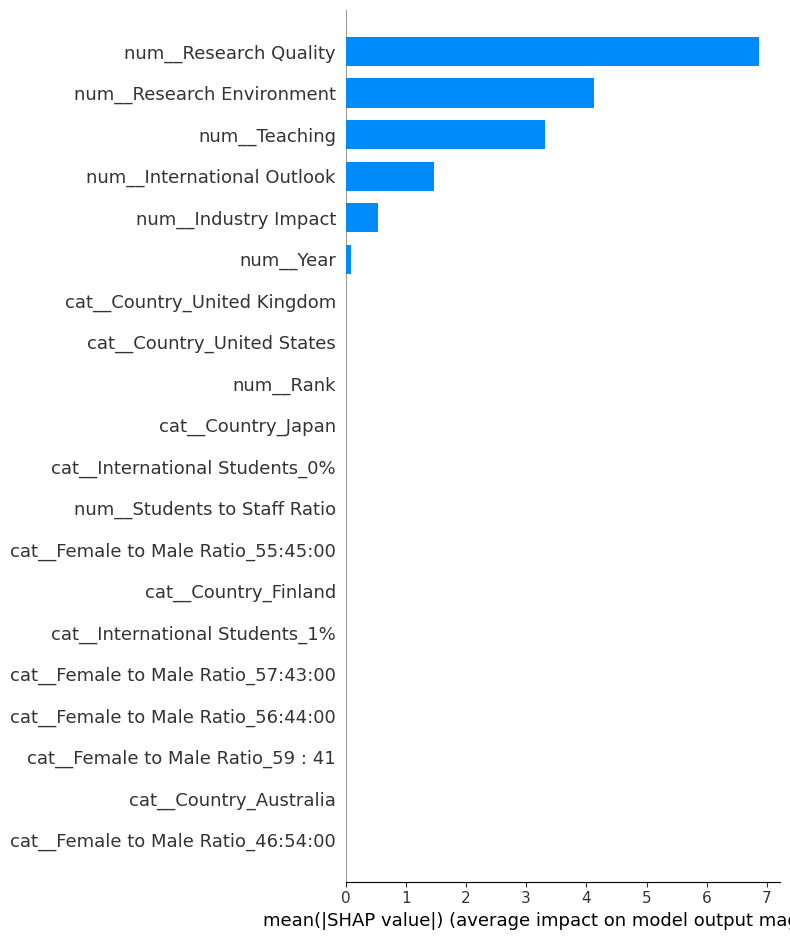


LINEAR REGRESSION — University Rankings
Accuracy (R²) = 0.9999
R2=0.9999 | MAE=0.1339 | RMSE=0.0304 | MAPE=0.0045
TrainTime(s)=2.901 | Inference(ms/sample)=0.0371

Readiness (0–5) breakdown:
  AccuracyScore(0-5)    : 4.9994
  Fairness(0-5)         : 4.9717
  Interpretability(0-5) : 4.1432
  DataQuality(0-5)      : 4.9620
  Scalability(0-5)      : 4.4680
  ✅ FINAL Readiness(0-5): 4.7354


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


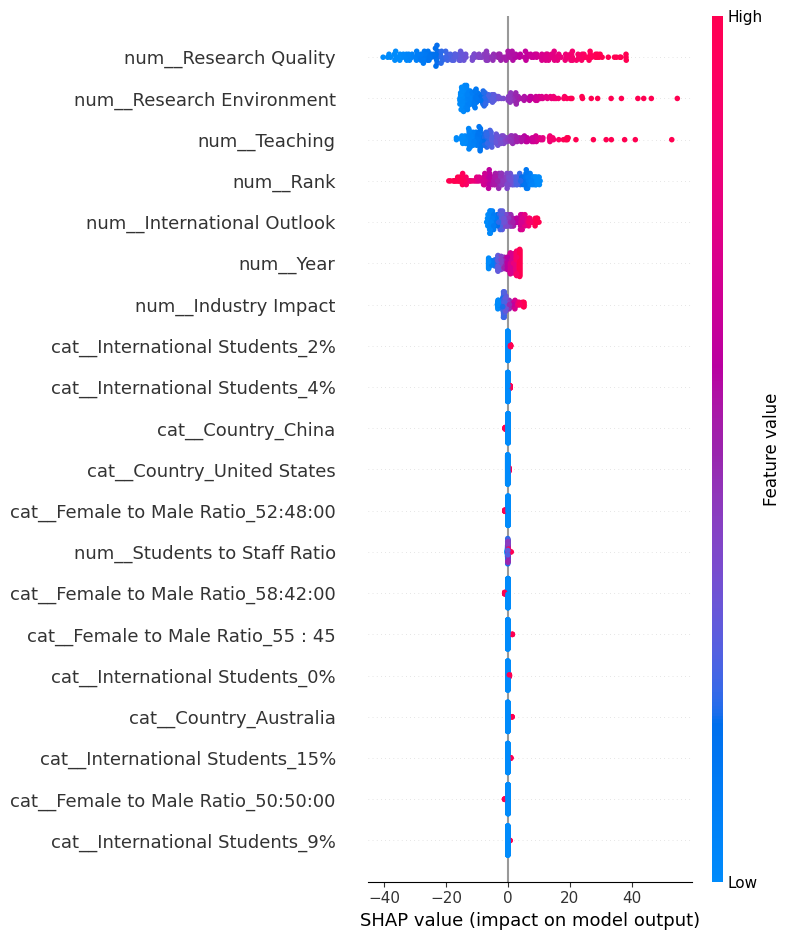

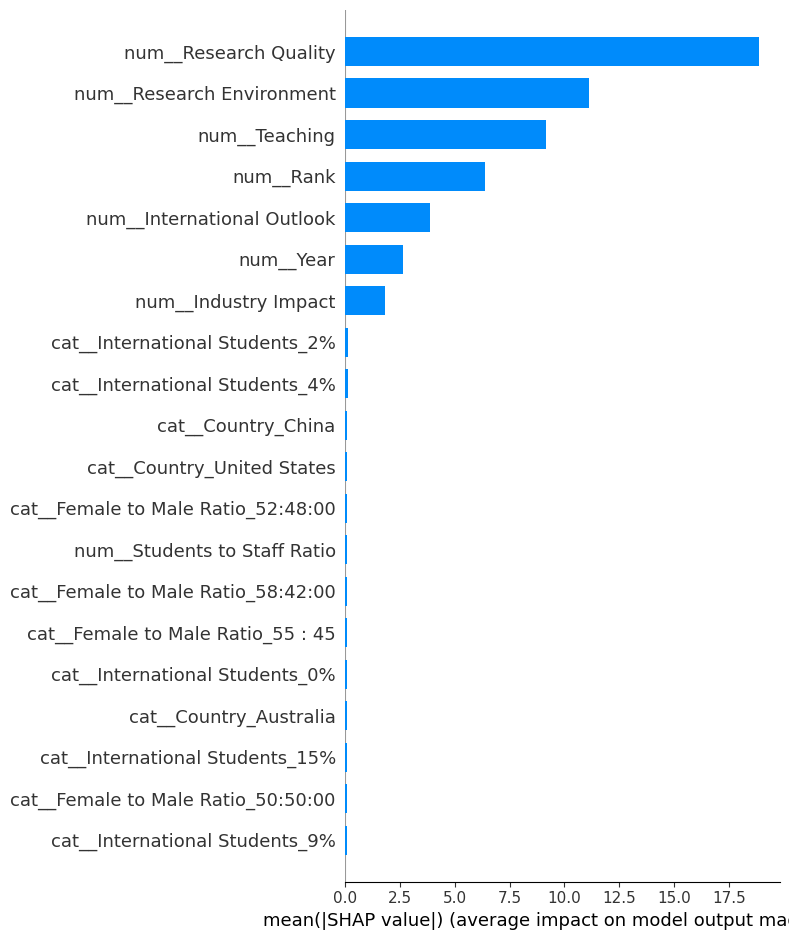


LOGISTIC REGRESSION (tuned) — Binary classification: OverallScore > median
Median threshold (train) = 32.8680
Accuracy=0.9931 | F1=0.9929
Tuning time (s) = 57.565
✅ Best params = {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 10.0}


In [ ]:

import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, f1_score

import shap
import matplotlib.pyplot as plt

shap.initjs()

# -------------------------
# CONFIG
# -------------------------
CSV_PATH = "/content/university_rankings/THE World University Rankings 2016-2026.csv"
TARGET = "Overall Score"
SHAP_SAMPLE = 200
RANDOM_STATE = 42

WEIGHTS = {  # your weights
    "Accuracy": 0.25,
    "Fairness": 0.20,
    "Interpretability": 0.20,
    "DataQuality": 0.20,
    "Scalability": 0.15,
}

# -------------------------
# Helpers
# -------------------------
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(1e-9, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)))

def data_quality_score_from_X(X_df: pd.DataFrame) -> float:
    total = X_df.size
    miss = X_df.isna().sum().sum()
    missing_ratio = 0.0 if total == 0 else miss / total
    score = 5.0 * (1.0 - min(1.0, 2.0 * missing_ratio))  # 0 if >=50% missing
    return float(np.clip(score, 0.0, 5.0))

def scalability_score(train_time_s: float, infer_ms_per_sample: float) -> float:
    # 5 - log10(1+time)*1.5 clipped; train(60%) + infer(40%)
    def f_seconds(t_sec: float):
        return float(np.clip(5.0 - np.log10(1.0 + max(0.0, t_sec)) * 1.5, 0.0, 5.0))

    train_component = f_seconds(train_time_s)
    infer_component = f_seconds((infer_ms_per_sample / 1000.0))  # ms -> sec
    return float(0.6 * train_component + 0.4 * infer_component)

def fairness_score_from_shap_bins(shap_2d: np.ndarray, preds: np.ndarray, K: int = 4) -> float:
    sv = np.array(shap_2d, dtype=float)
    preds = np.array(preds, dtype=float).reshape(-1)

    n = min(len(preds), sv.shape[0])
    if n < 10:
        return 2.5
    sv = sv[:n]
    preds = preds[:n]

    qs = np.quantile(preds, np.linspace(0, 1, K + 1))
    bins = []
    for k in range(K):
        mask = (preds >= qs[k]) & (preds <= qs[k+1] if k == K-1 else preds < qs[k+1])
        idx = np.where(mask)[0]
        if len(idx) > 0:
            bins.append(idx)

    if len(bins) < 2:
        return 2.5

    mus = [np.mean(np.abs(sv[idx]), axis=0) for idx in bins]
    dsum, cnt = 0.0, 0
    for i in range(len(mus)):
        for j in range(i + 1, len(mus)):
            dsum += float(np.mean(np.abs(mus[i] - mus[j])))
            cnt += 1

    div = dsum / max(1, cnt)
    score = 5.0 * (1.0 / (1.0 + 10.0 * div))
    return float(np.clip(score, 0.0, 5.0))

def interpretability_score_from_mean_abs(mean_abs: np.ndarray) -> float:
    v = np.abs(np.array(mean_abs, dtype=float))
    s = v.sum()
    if s <= 0:
        return 0.0
    p = v / s
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    conc = 1.0 - (entropy / max_entropy if max_entropy > 0 else 0.0)
    return float(np.clip(5.0 * conc, 0.0, 5.0))

def acc_score_0_5_regression(r2: float) -> float:
    return float(np.clip(5.0 * max(0.0, r2), 0.0, 5.0))

def acc_score_0_5_classification(acc: float) -> float:
    return float(np.clip(5.0 * acc, 0.0, 5.0))

def ms_per_sample(model, X, n=2000):
    Xs = X[: min(n, X.shape[0])]
    t0 = time.time()
    _ = model.predict(Xs)
    dt = time.time() - t0
    return float(1000.0 * dt / max(1, Xs.shape[0]))

# -------------------------
# Load + basic clean
# -------------------------
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.astype(str).str.strip()

if TARGET not in df.columns:
    raise KeyError(f"Target '{TARGET}' not found. Available: {df.columns.tolist()}")

# Drop obvious ID-like columns if present (optional; safe)
drop_cols = [c for c in df.columns if c.lower() in ["unnamed: 0", "name"]]
df = df.drop(columns=drop_cols, errors="ignore")

# Separate X/y
y = pd.to_numeric(df[TARGET], errors="coerce")
X = df.drop(columns=[TARGET]).copy()

# Remove rows where target missing
mask = y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

# Data quality score computed from raw X (before preprocessing)
dq = data_quality_score_from_X(X)

# Identify numeric vs categorical
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# ==========================================================
# 1) Linear Regression (Regression) -> readiness + SHAP
# ==========================================================
lin_pipe = Pipeline([("pre", pre), ("model", LinearRegression())])

t0 = time.time()
lin_pipe.fit(X_tr, y_tr)
train_time = time.time() - t0

y_hat = lin_pipe.predict(X_te)
r2 = r2_score(y_te, y_hat)
mae = mean_absolute_error(y_te, y_hat)
rmse = mean_squared_error(y_te, y_hat)
mape = safe_mape(y_te, y_hat)

# inference time on transformed dense/sparse OK via pipeline predict
infer_ms = ms_per_sample(lin_pipe, X_te.values if isinstance(X_te, np.ndarray) else X_te)

# ---- SHAP for LinearRegression on transformed matrix
Xt_tr = lin_pipe.named_steps["pre"].transform(X_tr)
Xt_te = lin_pipe.named_steps["pre"].transform(X_te)

Xt_tr_d = Xt_tr.toarray() if hasattr(Xt_tr, "toarray") else Xt_tr
Xt_te_d = Xt_te.toarray() if hasattr(Xt_te, "toarray") else Xt_te

try:
    feat_names = lin_pipe.named_steps["pre"].get_feature_names_out()
except Exception:
    feat_names = [f"feature_{i}" for i in range(Xt_te_d.shape[1])]

# sample for SHAP
idx = np.random.RandomState(RANDOM_STATE).choice(Xt_te_d.shape[0], size=min(SHAP_SAMPLE, Xt_te_d.shape[0]), replace=False)
Xt_te_s = Xt_te_d[idx]

# LinearExplainer works well for linear models
expl = shap.LinearExplainer(lin_pipe.named_steps["model"], Xt_tr_d, feature_perturbation="interventional")
sv = expl.shap_values(Xt_te_s)  # (n, p)

# plots
plt.figure()
shap.summary_plot(sv, Xt_te_s, feature_names=feat_names, show=False)
plt.tight_layout()
plt.show()

# SHAP BAR PLOT (feature importance)
plt.figure()
shap.summary_plot(
    sv,
    Xt_te_s,
    feature_names=feat_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()

# interpretability + fairness from SHAP
mean_abs = np.mean(np.abs(sv), axis=0)
interp = interpretability_score_from_mean_abs(mean_abs)

# fairness bins use predictions on the same sample
preds_s = lin_pipe.named_steps["model"].predict(Xt_te_s)
fair = fairness_score_from_shap_bins(sv, preds_s, K=4)

acc05 = acc_score_0_5_regression(r2)
sc = scalability_score(train_time, infer_ms)

readiness_lin = (
    WEIGHTS["Accuracy"] * acc05 +
    WEIGHTS["Fairness"] * fair +
    WEIGHTS["Interpretability"] * interp +
    WEIGHTS["DataQuality"] * dq +
    WEIGHTS["Scalability"] * sc
)

print("\n" + "="*90)
print("LINEAR REGRESSION — University Rankings")
print("="*90)
print(f"Accuracy (R²) = {r2:.4f}")
print(f"R2={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.4f}")
print(f"TrainTime(s)={train_time:.3f} | Inference(ms/sample)={infer_ms:.4f}")
print("\nReadiness (0–5) breakdown:")
print(f"  AccuracyScore(0-5)    : {acc05:.4f}")
print(f"  Fairness(0-5)         : {fair:.4f}")
print(f"  Interpretability(0-5) : {interp:.4f}")
print(f"  DataQuality(0-5)      : {dq:.4f}")
print(f"  Scalability(0-5)      : {sc:.4f}")
print(f"  ✅ FINAL Readiness(0-5): {readiness_lin:.4f}")

# ==========================================================
# 2) Logistic Regression (Classification) -> hyperparam tuning + SHAP
#    We create a binary label: AboveMedianScore
# ==========================================================
median_score = float(np.median(y_tr))
y_tr_cls = (y_tr > median_score).astype(int)
y_te_cls = (y_te > median_score).astype(int)

log_pipe = Pipeline([
    ("pre", pre),
    ("model", LogisticRegression(max_iter=2000))
])

param_dist = {
    "model__C": [0.01, 0.1, 1.0, 3.0, 10.0],
    "model__solver": ["lbfgs", "saga"],
    "model__penalty": ["l2"],
}

search = RandomizedSearchCV(
    estimator=log_pipe,
    param_distributions=param_dist,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

t0 = time.time()
search.fit(X_tr, y_tr_cls)
tune_time = time.time() - t0

best_log = search.best_estimator_
yhat_cls = best_log.predict(X_te)
acc = accuracy_score(y_te_cls, yhat_cls)
f1 = f1_score(y_te_cls, yhat_cls)

# SHAP for LogisticRegression (linear)
Xt_tr2 = best_log.named_steps["pre"].transform(X_tr)
Xt_te2 = best_log.named_steps["pre"].transform(X_te)

Xt_tr2_d = Xt_tr2.toarray() if hasattr(Xt_tr2, "toarray") else Xt_tr2
Xt_te2_d = Xt_te2.toarray() if hasattr(Xt_te2, "toarray") else Xt_te2

try:
    feat_names2 = best_log.named_steps["pre"].get_feature_names_out()
except Exception:
    feat_names2 = [f"feature_{i}" for i in range(Xt_te2_d.shape[1])]

idx2 = np.random.RandomState(RANDOM_STATE).choice(Xt_te2_d.shape[0], size=min(SHAP_SAMPLE, Xt_te2_d.shape[0]), replace=False)
Xt_te2_s = Xt_te2_d[idx2]

expl2 = shap.LinearExplainer(best_log.named_steps["model"], Xt_tr2_d, feature_perturbation="interventional")
sv2 = expl2.shap_values(Xt_te2_s)  # (n, p)

plt.figure()
shap.summary_plot(sv2, Xt_te2_s, feature_names=feat_names2, show=False)
plt.tight_layout()
plt.show()

# SHAP BAR PLOT (feature importance)
plt.figure()
shap.summary_plot(
    sv2,
    Xt_te2_s,
    feature_names=feat_names2,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()


print("\n" + "="*90)
print("LOGISTIC REGRESSION (tuned) — Binary classification: OverallScore > median")
print("="*90)
print(f"Median threshold (train) = {median_score:.4f}")
print(f"Accuracy={acc:.4f} | F1={f1:.4f}")
print(f"Tuning time (s) = {tune_time:.3f}")
print(f"✅ Best params = {search.best_params_}")


COMPREHENSIVE ML PIPELINE

Task type detected: Regression
Train shape: (13370, 13), Test shape: (3343, 13)

🔧 Training models (baseline + tuning)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2196
[LightGBM] [Info] Number of data points in the train set: 13370, number of used features: 209
[LightGBM] [Info] Start training from score 35.748341
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2196
[LightGBM] [Info] Number of data points in the train set: 13370, number of used features: 209
[LightGBM] [Info] Start training from score 35.748341

📌 BEFORE vs AFTER Hyperparameter Tuning (per model)

Model: RandomForest
  BEFORE:
Regression Accuracy (R2): 0.9993
Accuracy: None | F1: None
RMSE: 0.4414 | MAE: 

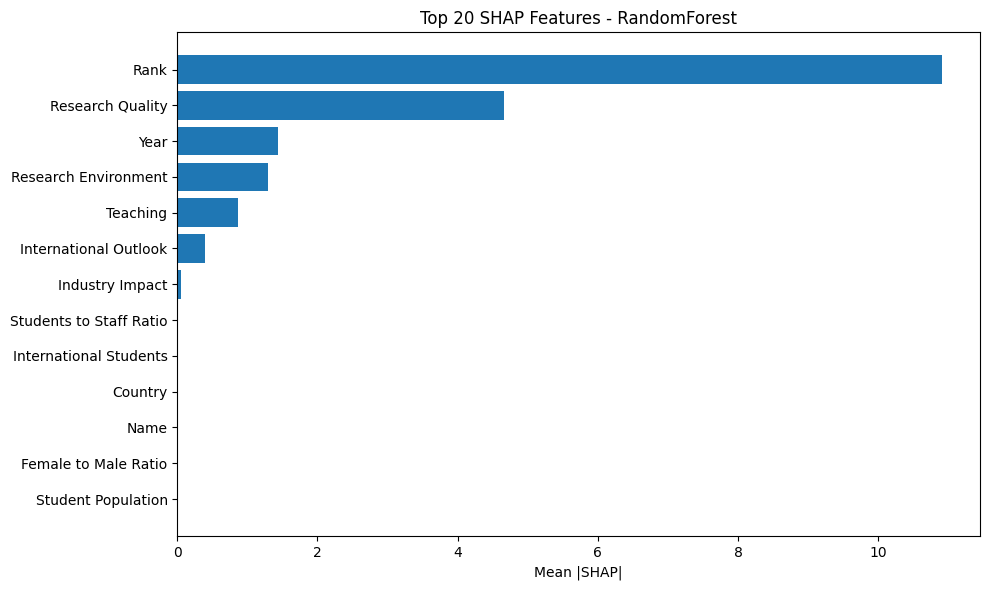

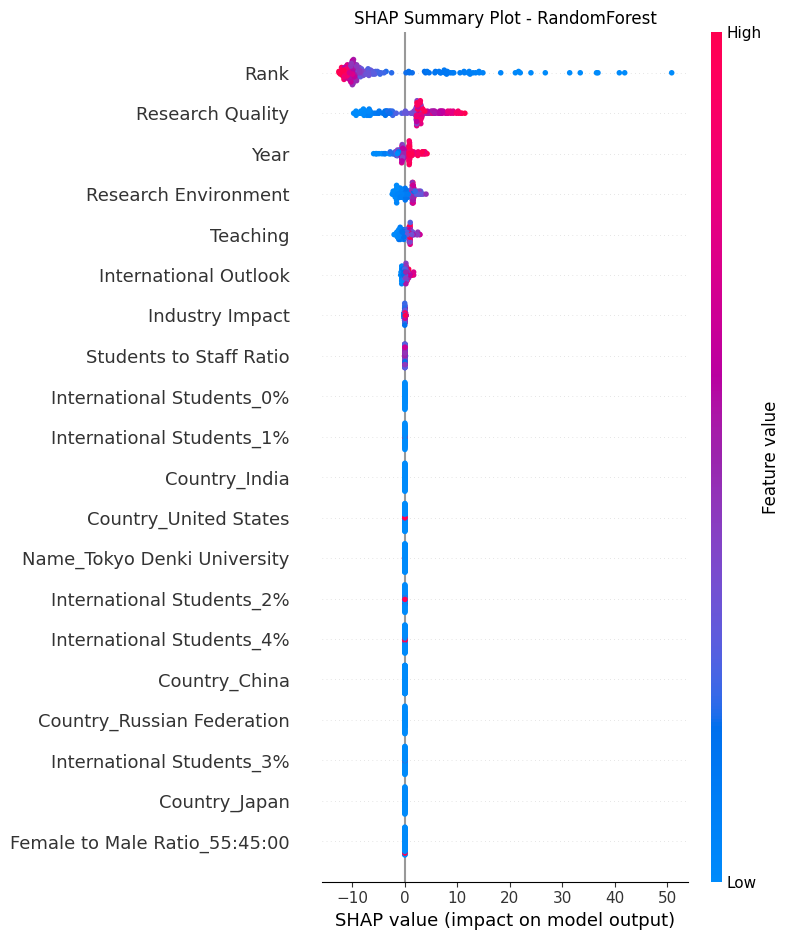

  ✅ SHAP displayed + saved:
     - shap_outputs/RandomForest_shap_bar.png
     - shap_outputs/RandomForest_shap_summary.png

Running SHAP for: HistGB


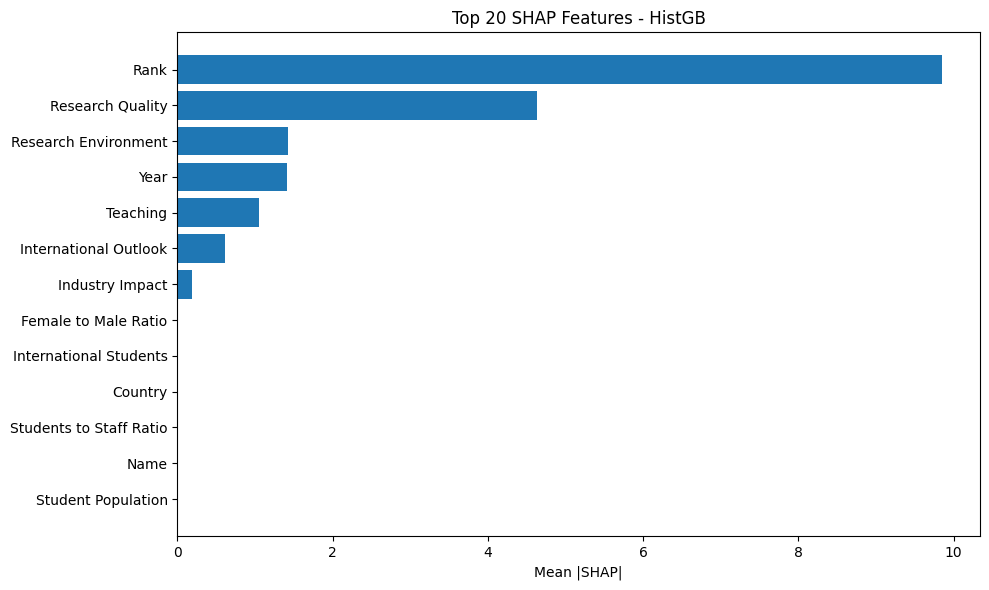

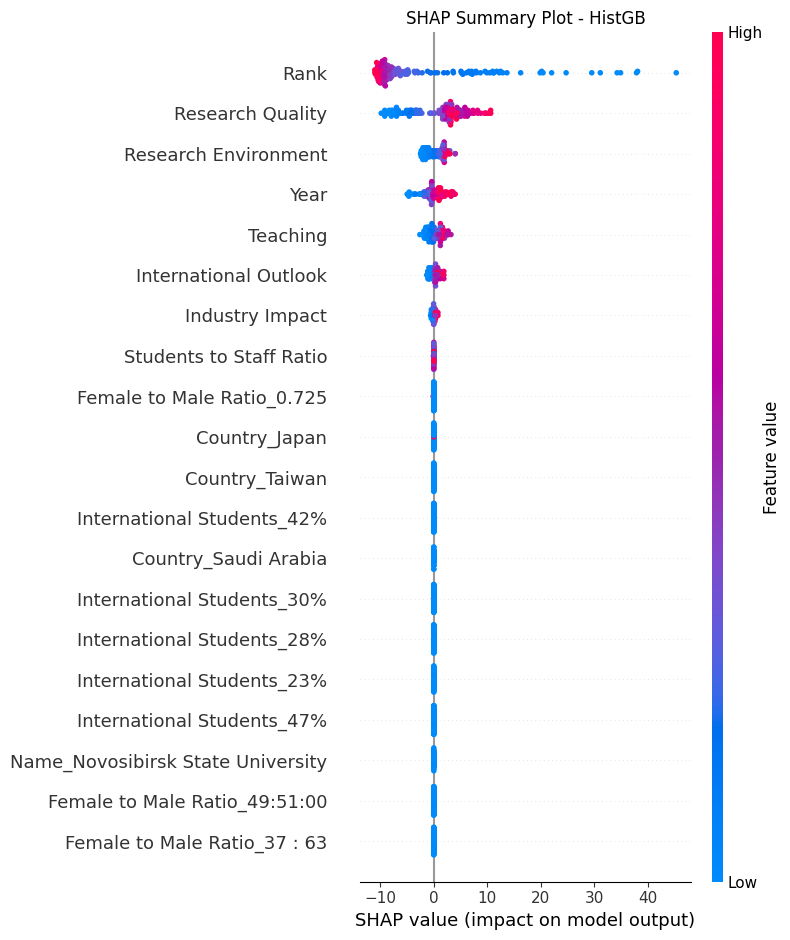

  ✅ SHAP displayed + saved:
     - shap_outputs/HistGB_shap_bar.png
     - shap_outputs/HistGB_shap_summary.png

Running SHAP for: XGBoost


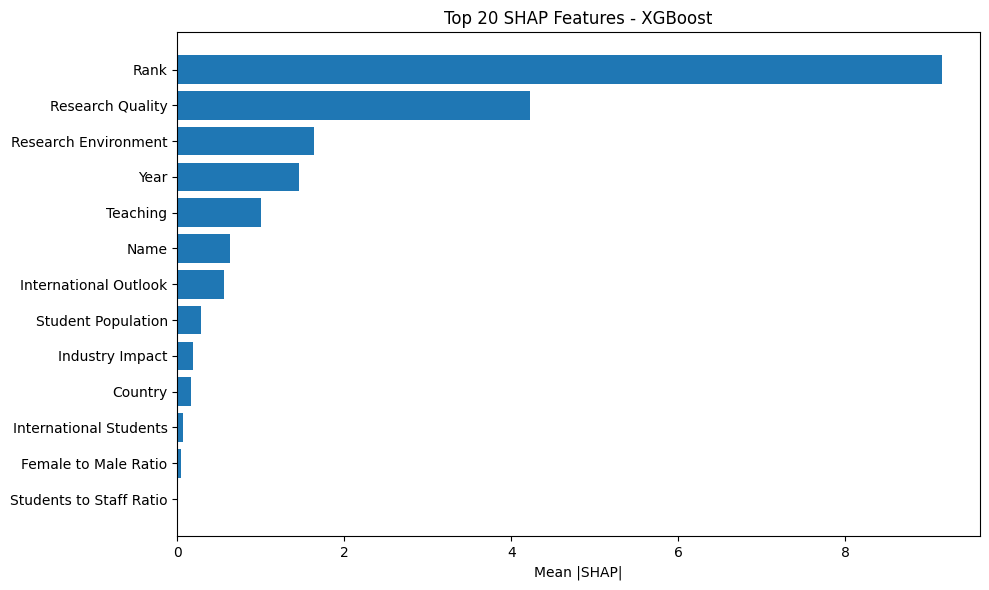

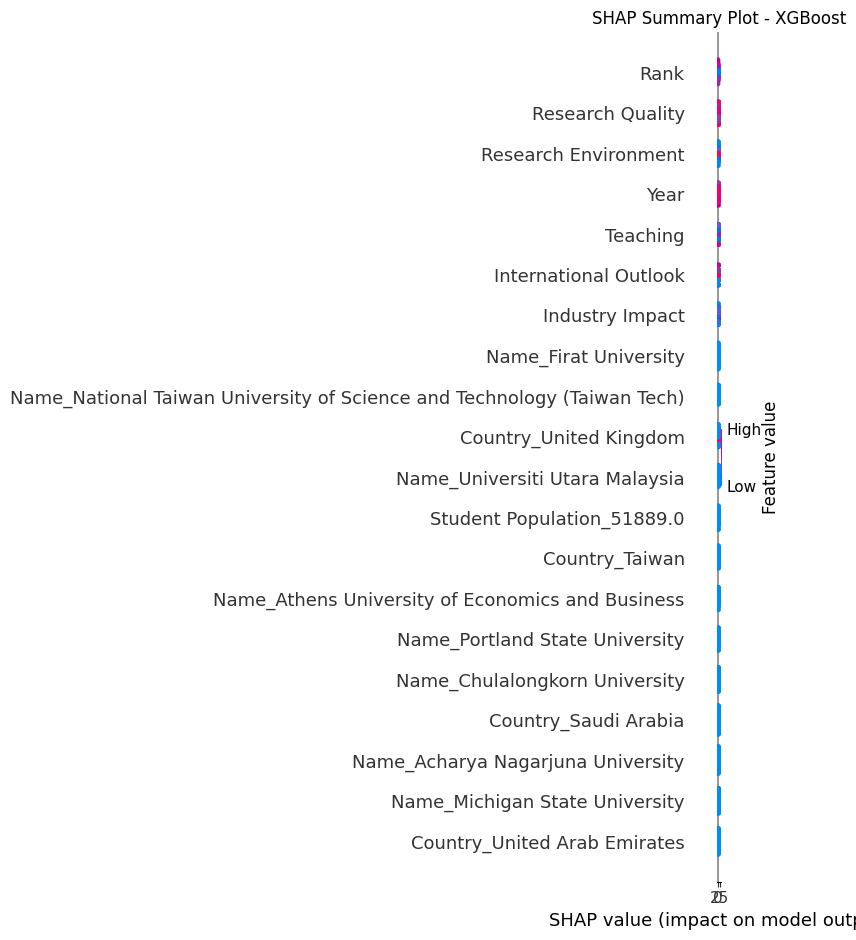

  ✅ SHAP displayed + saved:
     - shap_outputs/XGBoost_shap_bar.png
     - shap_outputs/XGBoost_shap_summary.png

Running SHAP for: LightGBM


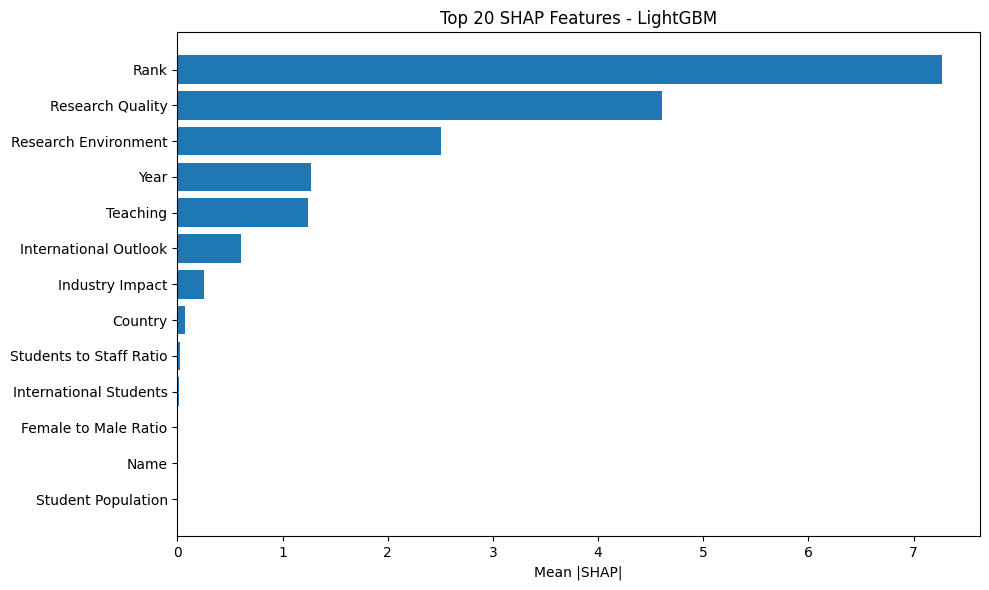

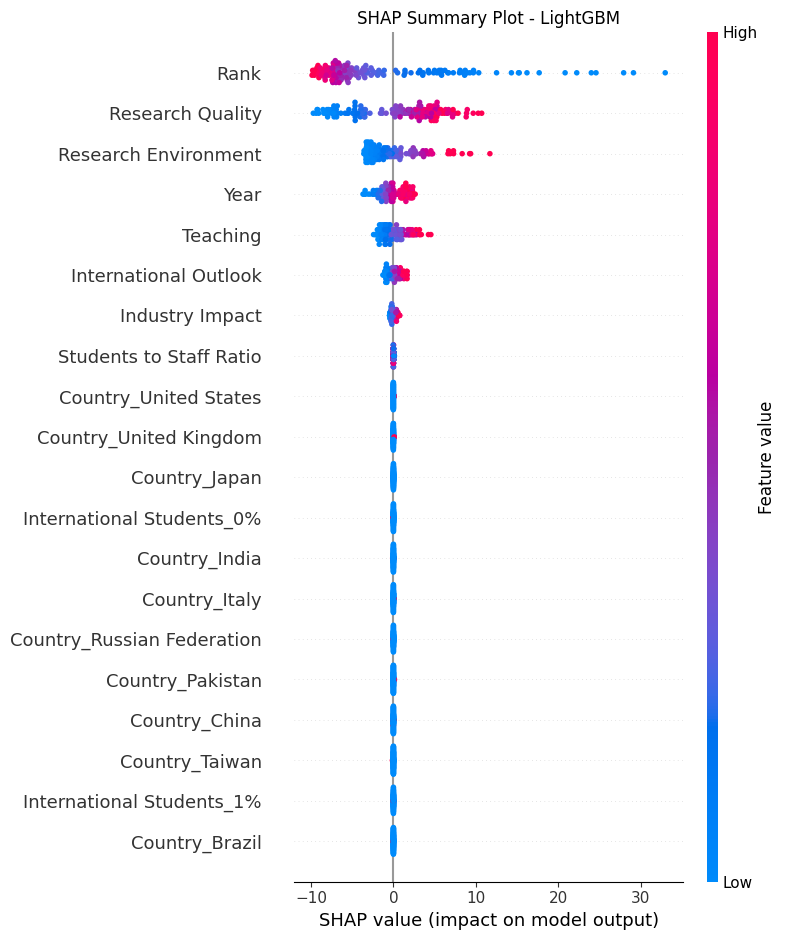

  ✅ SHAP displayed + saved:
     - shap_outputs/LightGBM_shap_bar.png
     - shap_outputs/LightGBM_shap_summary.png

📊 EDUCATIONAL AI READINESS SCORE (per model, 0–5)

Model: RandomForest
  Data Quality     : 4.965
  Accuracy         : 4.998
  Interpretability : 4.328
  Scalability      : 2.007
  Fairness         : 3.996
  ✅ Readiness Score: 4.208

Model: HistGB
  Data Quality     : 4.965
  Accuracy         : 4.999
  Interpretability : 4.269
  Scalability      : 1.964
  Fairness         : 4.048
  ✅ Readiness Score: 4.201

Model: XGBoost
  Data Quality     : 4.965
  Accuracy         : 4.999
  Interpretability : 3.997
  Scalability      : 2.8
  Fairness         : 4.035
  ✅ Readiness Score: 4.269

Model: LightGBM
  Data Quality     : 4.965
  Accuracy         : 4.999
  Interpretability : 4.171
  Scalability      : 3.517
  Fairness         : 4.112
  ✅ Readiness Score: 4.427


In [ ]:
results_rankings = comprehensive_ml_pipeline(
    dataset_path="/content/university_rankings/THE World University Rankings 2016-2026.csv",
    target_column="Overall Score",
    task_type="auto",
    fast_mode="auto",      # activates fast defaults
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=False
)
